<table style="width:100%">
<tr>
<td style="vertical-align:middle; text-align:left;">
<font size="2">
Supplementary code for the <a href="http://mng.bz/orYv">Build a Large Language Model From Scratch</a> book by <a href="https://sebastianraschka.com">Sebastian Raschka</a><br>
<br>Code repository: <a href="https://github.com/rasbt/LLMs-from-scratch">https://github.com/rasbt/LLMs-from-scratch</a>
<br>汉化的库: <a href="https://github.com/GoatCsu/CN-LLMs-from-scratch.git">https://github.com/GoatCsu/CN-LLMs-from-scratch.git</a>
</font>
</td>
<td style="vertical-align:middle; text-align:left;">
<a href="http://mng.bz/orYv"><img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/cover-small.webp" width="100px"></a>
</td>
</tr>
</table>


# 第 6 章：进行文本分类的微调

In [69]:
from importlib.metadata import version

pkgs = ["matplotlib",
        "numpy",
        "tiktoken",
        "torch",
        "tensorflow", # 用于加载OpenAI的预训练权重的TensorFlow库
        "pandas"      # 用于加载数据集的库
       ]
for p in pkgs:
    print(f"{p} version: {version(p)}")
#查看版本号Ω

matplotlib version: 3.10.9
numpy version: 2.4.6
tiktoken version: 0.13.0
torch version: 2.12.0
tensorflow version: 2.21.0
pandas version: 3.0.3


<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch6/1.png" width="400px">

In [70]:
# 防止某些单元格执行两次
from IPython.core.magic import register_line_cell_magic

executed_cells = set()
#使用一个 set 数据结构来存储已经执行过的单元格标识符
@register_line_cell_magic
#注册了一个名为 run_once 的魔法命令
def run_once(line, cell):
    if line not in executed_cells:
        get_ipython().run_cell(cell)
        executed_cells.add(line)
    else:
        print(f"Cell '{line}' has already been executed.")

## 6.1 不同类型的微调

- 本章节没有代码

- 常见微调大语言模型的方法包括：指令微调( instructionfinetuning)和分类微调(classification finetuning)
- 如下是:指令微调，也是下一章节所要讲的内容

<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch6/2.png" width=500px>

- 如果您具有机器学习的背景，对于分类微调您可能已经熟悉. 举个例子，分类微调类似于训练卷积网络来对手写数字进行分类的过程
- 在分类微调中，模型可以输出特定的分类标签（例如，“spam”和“not spam”）
- 分类微调模型只能预测它在训练期间所熟知的类别标签（例如，“垃圾邮件”或“非垃圾邮件”），而指令微调模型通常可以执行更广泛的任务
- 我们可以将分类微调模型视为高度专业化的模型;在实践中，开发专业化的模型通常比开发在许多不同任务上表现良好的通用模型要容易得多

<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch6/3.png" width=500px>

## 6.2 准备数据集

<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch6/4.png" width=500px>

- 本节准备我们用于分类微调的数据集
- 我们使用由垃圾邮件和非垃圾邮件组成的数据集来对 LLM 进行分类微调
- 首先，我们下载并解压缩数据集

In [71]:
import urllib.request     # 导入用于从网络下载文件的工具库
import zipfile            # 导入用于解压 zip 压缩包的工具库
import os                 # 导入操作系统相关功能（比如重命名文件）
from pathlib import Path  # 导入路径处理工具，让文件路径操作更简单

# ------------------- 配置部分 -------------------
# 要下载的数据集压缩包的网络地址
url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
# 下载到本地后，压缩包保存的文件名
zip_path = "sms_spam_collection.zip"
# 解压后文件存放的文件夹名称
extracted_path = "sms_spam_collection"
# 最终需要的 tsv 数据文件路径（拼接文件夹 + 文件名）
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

# 定义一个函数：下载短信垃圾邮件数据集，并自动解压、重命名
def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    # 先检查：目标数据文件是否已经存在
    if data_file_path.exists():
        # 如果已经存在，就不用重复下载了，打印提示信息
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        # 直接结束函数，不执行后面的下载代码
        return
    # ------------------- 开始下载文件 -------------------
    # 打开网络链接，获取文件数据
    with urllib.request.urlopen(url) as response:
        # 以二进制写入模式打开本地文件
        with open(zip_path, "wb") as out_file:
            # 把从网上读到的数据写入本地文件
            out_file.write(response.read())
    # ------------------- 开始解压文件 -------------------
    # 打开刚才下载的 zip 压缩包
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        # 把压缩包里的所有文件解压到指定文件夹
        zip_ref.extractall(extracted_path)
    # ------------------- 重命名文件 -------------------
    # 解压出来的原始文件没有后缀名，先获取它的路径
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    # 把原始文件重命名为带 .tsv 后缀的文件（方便后续读取处理）
    os.rename(original_file_path, data_file_path)
    # 打印成功提示
    print(f"File downloaded and saved as {data_file_path}")

# ------------------- 调用函数，开始执行下载 -------------------
download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

sms_spam_collection\SMSSpamCollection.tsv already exists. Skipping download and extraction.


- 数据集保存为一个以制表符分隔的文本文件SMSSpamCollection.tsv，位于 SMSSpamCollection 文件夹中。我们可以使用以下代码将其加载到 pandas DataFrame 中

In [72]:
import pandas as pd

df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


- 执行如下代码来查看数据集中的数据类别分布，会发现数据中“非垃圾消息（ham）”的出现频率远高于“垃圾消息（spam）”

In [73]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


- 为了简化处理，并且出于教学目的考虑，我们选择使用小规模数据集，这有助于更快地对大语言模型进行微调。因此，我们对数据集进行了下采样，使每个类别包含 747 个实例。
- （除了下采样之外，还有其他几种方法可以处理类别不平衡，但这些超出了本书的范围; 你可以在 imbalanced-learn 中找到示例和更多信息）[`imbalanced-learn` 用户指南](https://imbalanced-learn.org/stable/user_guide.html)

In [74]:
%%run_once balance_df  # %%run_once 是Jupyter专用命令：保证这个单元格只执行1次，避免重复打乱数据
import pandas as pd

# 定义函数：创建均衡数据集：让垃圾短信(spam)和正常短信(ham)的数量一样多，防止模型偏向数量多的一方
def create_balanced_dataset(df):
    # 1. 统计数据集中【垃圾短信 spam】的总数量
    # df[df["Label"] == "spam"] 筛选出所有垃圾短信
    # .shape[0] 取行数 = 样本个数
    num_spam = df[df["Label"] == "spam"].shape[0]
    # 2. 从【正常短信 ham】中随机抽取 和垃圾短信数量一样多 的样本
    # sample(数量)：随机抽取
    # random_state=123：固定随机种子，保证每次抽取结果一样，方便复现
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)
    # 3. 把 抽出来的正常短信 和 全部垃圾短信 拼接在一起
    # 拼接后两类数据数量相等，数据集变得均衡
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])
    # 把处理好的均衡数据集返回，供外面使用
    return balanced_df

# 调用上面的函数，传入原始数据 df，得到均衡后的数据集
balanced_df = create_balanced_dataset(df)
# 打印查看均衡后 正常短信(ham) 和 垃圾短信(spam) 各自的数量（会看到两个数字完全一样，说明均衡成功）
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


- 随后我们把标签 "ham" 和 "spam" 转换为整数类标签“0”和“1”:

In [75]:
%%run_once label_mapping
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})    

In [76]:
balanced_df

,Label,Text
4307,0,Awww dat is sweet! We can think of something t...
4138,0,Just got to &lt;#&gt;
4831,0,"The word ""Checkmate"" in chess comes from the P..."
4461,0,This is wishing you a great day. Moji told me ...
5440,0,Thank you. do you generally date the brothas?
...,...,...
5537,1,Want explicit SEX in 30 secs? Ring 02073162414...
5540,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547,1,Had your contract mobile 11 Mnths? Latest Moto...
5566,1,REMINDER FROM O2: To get 2.50 pounds free call...


- 现在自定义一个函数,用于把数据集随机划分为训练集、验证集、测试集

In [77]:
# 定义函数：随机将数据集切分为 训练集、验证集、测试集
# df：要切分的完整数据集、train_frac：训练集占比（例如0.7=70%）、validation_frac：验证集占比（例如0.1=10%）
def random_split(df, train_frac, validation_frac):
    # 1. 打乱数据集的顺序： frac=1：抽取全部数据（相当于打乱）、reset_index(drop=True)：打乱后重置行索引，去掉原来的旧索引
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)
    # 2. 计算切分的位置（下标）
    train_end = int(len(df) * train_frac)  # 训练集结束的索引位置 = 总长度 * 训练集占比
    validation_end = train_end + int(len(df) * validation_frac)   # 验证集结束的索引位置 = 训练集结束位置 + 总长度 * 验证集占比
    # 3. 按照计算好的位置，把数据切成三部分
    train_df = df[:train_end]          # 从开头到 train_end → 训练集
    validation_df = df[train_end:validation_end]  # 中间部分 → 验证集
    test_df = df[validation_end:]      # 剩下的所有数据 → 测试集
    # 返回切分好的三个数据集
    return train_df, validation_df, test_df
# 调用切分函数，传入均衡后的数据集：训练集70% + 验证集10% + 测试集20% = 100%
train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)
# 把三个数据集分别保存成 CSV 文件，方便后续直接读取使用、 index=None：不保存行索引，让文件更干净
train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

## 6.3 创建数据加载器

- 由于文本消息长度随机,因此在批量化组合训练数据之前要做数据归一化,我们有两种操作可供选择
  1. 将所有消息截断到数据集中最短消息的长度或批次长度
  2. 将所有消息填充到数据集中最长消息的长度或批次长度

- 这里我们选择操作2,填充数据
- 并且,我们使用`<|endoftext|>` 作为填充标识符

<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch6/5.png" width=500px>

In [78]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
# 打印<|endoftext|>对应的词元id
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


- 下面我们首先将 `SpamDataset` 训练数据集中最长的序列，然后将填充token（<|endoftext|>）添加到其他序列末端以匹配该序列长度

In [79]:
import torch
from torch.utils.data import Dataset  # 导入PyTorch数据集基类
# 自定义数据集类：用于加载和处理短信垃圾邮件数据
class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)  # 读取CSV数据文件
        self.encoded_texts = [tokenizer.encode(text) for text in self.data["Text"]]  # 对所有文本进行编码，转换为模型可识别的数字ID
        # 设置序列最大长度
        if max_length is None:
            self.max_length = self._longest_encoded_length()  # 未指定则自动使用数据中最长的序列长度
        else:
            self.max_length = max_length
            self.encoded_texts = [encoded_text[:self.max_length] for encoded_text in self.encoded_texts]  # 使用指定最大长度，并截断超长序列
        # 对所有序列进行填充，保证长度一致
        self.encoded_texts = [encoded_text + [pad_token_id] * (self.max_length - len(encoded_text)) for encoded_text in self.encoded_texts]

    # 获取单个数据样本（PyTorch训练时必需）
    def __getitem__(self, index):
        # 获取指定索引的编码文本和标签
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        # 转换为PyTorch张量并返回
        return torch.tensor(encoded, dtype=torch.long), torch.tensor(label, dtype=torch.long)

    # 返回数据集总样本数（PyTorch训练时必需）
    def __len__(self):
        return len(self.data)

    # 辅助函数：计算编码后最长的序列长度
    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:  # 遍历所有序列，找出最长长度
            max_length = max(max_length, len(encoded_text))
        return max_length

In [80]:
train_dataset = SpamDataset(
    csv_file="train.csv",
    max_length=None,
    tokenizer=tokenizer
)

print(train_dataset.max_length)

120


- 我们还将验证和测试集填充到最长的训练序列
- 在本节代码中,任何超过最长训练示例长度的验证集和测试集样本都将使用之前定义的 `SpamDataset` 中的代码 `encoded_text[:self.max_length]`进行截断
- 此行为完全是可选的，如果我们在验证和测试集情况下都设置 `max_length=Non`，代码也能正常运行

In [81]:
# 将验证集和测试集数据填充到最长序列的长度
val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)
test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

- 接下来，我们使用数据集来实例化数据加载器，这与前几章中创建数据加载器类似

<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch6/6.png" width=500px>

In [82]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

# 设置种子确保可复现
torch.manual_seed(123)
# 初始化数据加载器
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)
# 对齐超参数,但是dataset需要区别一下训练集、验证集和测试集

- 作为验证步骤，我们遍历数据加载器，并确保每个批次包含 8 个训练样本，其中每个训练样本由 120 个 token 组成

In [83]:
print("Train loader:")
for input_batch, target_batch in train_loader:
    pass
    #如果这个数据在训练集出现过,则跳过

print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

Train loader:
Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])


- 最后，让我们通过打印来查看每个数据集的批次数目

In [84]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


## 6.4 用预训练权重初始化模型

- 在本节中，我们将初始化在上一章中使用的预训练模型

<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch6/7.png" width=500px>

In [85]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size": 50257,     # 词表大小
    "context_length": 1024,  # 上下文长度
    "drop_rate": 0.0,        # Dropout率
    "qkv_bias": True         # 查询-键-值偏置
}
# 输入超参数
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}
# 输入模型的参数
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

assert train_dataset.max_length <= BASE_CONFIG["context_length"], (
    f"Dataset length {train_dataset.max_length} exceeds model's context "
    f"length {BASE_CONFIG['context_length']}. Reinitialize data sets with "
    f"`max_length={BASE_CONFIG['context_length']}`"
)
# 断言语句，用于验证 train_dataset.max_length 是否符合模型的上下文长度（context_length）要求。
# 如果不符合，将抛出一个异常的讯号

In [86]:
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")
# 引入超参数跟模型设置
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 191kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:06<00:00, 168kiB/s] 
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 114kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [34:50<00:00, 238kiB/s]     
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 5.12MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:00<00:00, 480kiB/s]  
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 476kiB/s]  


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

- 为了确保模型已正确加载，让我们仔细检查它是否生成了连贯的文本

In [87]:
from previous_chapters import (
    generate_text_simple,
    text_to_token_ids,
    token_ids_to_text
)


text_1 = "Every effort moves you"

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)
# 生成文本
print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


- 在我们将模型微调为分类器之前，让我们看看该模型是否已经可以通过提示对垃圾邮件进行分类

In [88]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


- 正如我们所看到的，该模型不太擅长遵循指示
- 这是意料之中的，因为它只是经过了预训练，还没有经过指令微调（指令微调将在下一章中介绍）

## 6.5 添加分类头

<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch6/8.png" width=500px>

- 在本节中，我们将修改预训练的 LLM，为分类微调做准备
- 首先，让我们先看一下模型的架构

In [89]:
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

- 我们可以看到,在第 4 章中实现的架构
- 我们的目标是替换和微调输出层
- 为了实现这一点，我们首先冻结模型，这意味着我们使所有层都是不可训练的

In [90]:
for param in model.parameters():
    param.requires_grad = False
# 返回 model 中所有的参数,但是不参与反向传播

- 然后，我们替换输出层`(model.out_head)`，它最初将层输入映射到 50,257 个维度（词汇表的大小）
- 由于我们对二元分类模型进行了微调（预测 2 个类别，“spam”和“not spam”），因此我们可以替换如下所示的输出层，默认情况下它是可训练的
- 我们使用 `BASE_CONFIG["emb_dim"]`（在 “gpt2-small （124M）” 模型中为 768）来保持下面的代码更通用

In [91]:
torch.manual_seed(123)

num_classes = 2
model.out_head = torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"], out_features=num_classes)

- 从技术上讲，只需训练输出层就足够了
- 但是，正如在 [Finetuning Large Language Models](https://magazine.sebastianraschka.com/p/finetuning-large-language-models)中表明，微调其他层可以显著提高性能
- 因此，我们还使最后一个 transformer 模块和最后一个 `LayerNorm` 模块连接起来，将最后一个 transformer 模块连接到输出层，使其可训练

<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch6/9.png" width=500px>

In [92]:
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

for param in model.final_norm.parameters():
    param.requires_grad = True
# 对于需要更新权重则设将该参数设置为True

- 即使我们添加了新的输出层并标记了某些层为可训练或不可训练，我们仍然可以像之前一样使用这个模型
- 例如,我们输入点文本

In [93]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape)
# 编码并输出

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])


- 与前几章相比，它现在有两个输出维度，而不再是 50,257 个

In [94]:
with torch.no_grad():
    outputs = model(inputs)

print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape) # 形状：（批次大小，词元数量）

Outputs:
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
Outputs dimensions: torch.Size([1, 4, 2])


- 如前几章所述，对于每个 input token，模型都会返回一个 output vector
- 由于我们向模型提供了具有 4 个输入 token 的文本样本，因此输出由上面的 4 个 2 维输出向量组成

<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch6/10.png" width=500px>

- 在第 3 章中，我们讨论了attention机制，它将每个输入 token 连接到另一个输入 token
- 在第 3 章中，我们还介绍了类 GPT 模型中使用的因果注意力掩码(causal attention mask);这种掩码让当前token只关注当前和先前出现过的位置
- 基于这种因果注意力机制，第 4 个（最后一个）token在所有token中包含最多的信息，因为唯一包含所有其他全部信息只有它
- 因此，我们在微调过程中格外关注这个最后的词元

In [95]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]])


<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch6/11.png" width=200px>

## 6.6 计算分类损失和准确率

<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch6/12.png" width=500px>

- 在解释损失计算之前，让我们简单了解一下模型输出是如何转换为类标签的

<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch6/13.png" width=600px>

In [96]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]])


- 与第 5 章类似，我们通过 `softmax` 函数将输出 （logits） 转换为概率分数，然后通过`argmax`函数获得最大概率值的索引位置

In [97]:
probas = torch.softmax(outputs[:, -1, :], dim=-1)
label = torch.argmax(probas)
print("Class label:", label.item())

Class label: 1


- 如第 5 章所述，softmax 函数在这里是可选的，因为最大的输出对应于最大的概率分数

In [98]:
logits = outputs[:, -1, :]
label = torch.argmax(logits)
print("Class label:", label.item())

Class label: 1


- 我们可以应用这个概念来计算所谓的"分类准确性"，计算给定数据集中正确预测的百分比
- 为了计算分类准确率，我们可以将前面基于 `argmax` 的预测代码应用于数据集中的所有示例，并按如下方式计算正确预测的分数：

In [99]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0
    # 先改成评估模式,在初始化两个储存器
    if num_batches is None:
        num_batches = len(data_loader)
        # num_batches设为None则取全部数据
    else:
        num_batches = min(num_batches, len(data_loader))
        # 取num_batches和len(data_loader)中较小的那个
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)
            # 仅处理前 num_batches 批次的数据
            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]  # 最后一个输出词元的概率
            # 预测内容取概率最大值
            predicted_labels = torch.argmax(logits, dim=-1)
            # 当前批次的样本数
            num_examples += predicted_labels.shape[0]
            # 预测正确的样本数量
            correct_predictions += (predicted_labels == target_batch).sum().item()
            
        else:
            break
    return correct_predictions / num_examples

- 用该函数计算不同数据集的分类精度

In [100]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#Note:

#取消注释以下行将允许代码在 Apple Silicon 芯片上运行（如果适用），
#这比在 Apple CPU 上运行快大约 2 倍（根据 M3 MacBook Air 的测量结果）。
#截至目前，在 PyTorch 2.4 版本中，通过 CPU 和 MPS 得到的结果是相同的。
#然而，在 PyTorch 的早期版本中，使用 MPS 时，可能会观察到不同的结果。
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Running on {device} device.")

model.to(device) # 对于 nn.Module 类，无需 model = model.to(device)赋值操作

torch.manual_seed(123) # 由于训练数据加载器中的随机打乱，因此设置随机种子以确保可重复性

train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=10)
#各种计算
print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Running on cpu device.
Training accuracy: 46.25%
Validation accuracy: 45.00%
Test accuracy: 48.75%


- 可以看到，预测的准确性不是很好，这是因为因为我们还没有对模型进行微调

- 在开始微调 （/training） 之前，我们首先必须定义要在训练期间优化的损失函数
- 目标是最大限度地提高模型的垃圾邮件分类准确性;
- 由于分类准确率不是可微分的，我们使用交叉熵损失作为最大化准确率的替代（您可以在我免费提供的[深度学习入门课程](https://sebastianraschka.com/blog/2021/dl-course.html#l08-multinomial-logistic-regression--softmax-regression)的第 8 讲中了解有关此主题的更多信息）

- `calc_loss_batch` 函数与第 5 章相同，只是我们只对优化最后一个 `tokens model（input_batch）``[：， -1， ：]` 感兴趣，而不是所有 `tokens model（input_batch）`

In [101]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)[:, -1, :]  # Logits of last output token
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss
    #用交叉熵计算损失函数

使用 `calc_closs_loader`，我们在开始训练之前计算初始训练集、验证集和测试集损失

In [102]:

def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # 如果 num_batches 超过数据加载器中的批次数，则减少批次数以匹配数据加载器中的总批次数
        # num_batches = min(num_batches, len(data_loader))
        for i, (input_batch, target_batch) in enumerate(data_loader):
            if i < num_batches:
                loss = calc_loss_batch(input_batch, target_batch, model, device)
                # 总损失值
                total_loss += loss.item()
            
            else:
                break
    return total_loss / num_batches
    

In [103]:
with torch.no_grad(): # 因为我们不进行训练，所以为了提高效率禁用梯度跟踪
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 2.453
Validation loss: 2.583
Test loss: 2.322


- 在下一节中，我们将训练模型以最小化损失值，从而提高分类准确率

## 6.7 在有监督数据上微调模型

- 在本节中，我们将定义并使用训练函数来提高模型的分类准确率
- 下面的 `train_classifier_simple` 函数实际上与我们在第 5 章中用于预训练模型的 `train_model_simple `函数相同
- 唯二区别
  1. 我们现在跟踪的是已经看到的训练样本数量（examples_seen），而不是token数量
  2. 我们在每个周期后计算准确率，而不是打印一个样例文本

<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch6/14.png" width=500px>

In [104]:
# 跟第五章的一摸一样那就当重新复习了
def train_classifier_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                            eval_freq, eval_iter):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1
    # 初始化分类头
    for epoch in range(num_epochs):
        model.train()  
        # 每次都进入训练模块
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() 
            # 清零梯度
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() 
            # 对损失值执行反向传播记录梯度
            optimizer.step() 
            # 用梯度优化权重
            examples_seen += input_batch.shape[0] 
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

- `evaluate_model` 在`train_classifier_simple` 是跟第五章相同的

In [105]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss
    # 调用辅助函数 calc_loss_loader 计算模型在 训练集、验证集上的损失

- M3 MacBook Air五分钟训练完
- V100 or A100 GPU大概用半分钟

In [106]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

num_epochs = 5
train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50, eval_iter=5,
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")
# 输出每一次的损失值跟在一定频次下进行准确率输出

Ep 1 (Step 000000): Train loss 2.153, Val loss 2.392
Ep 1 (Step 000050): Train loss 0.617, Val loss 0.637
Ep 1 (Step 000100): Train loss 0.523, Val loss 0.557
Training accuracy: 70.00% | Validation accuracy: 72.50%
Ep 2 (Step 000150): Train loss 0.561, Val loss 0.489
Ep 2 (Step 000200): Train loss 0.419, Val loss 0.397
Ep 2 (Step 000250): Train loss 0.409, Val loss 0.353
Training accuracy: 82.50% | Validation accuracy: 85.00%
Ep 3 (Step 000300): Train loss 0.333, Val loss 0.320
Ep 3 (Step 000350): Train loss 0.340, Val loss 0.306
Training accuracy: 90.00% | Validation accuracy: 90.00%
Ep 4 (Step 000400): Train loss 0.136, Val loss 0.200
Ep 4 (Step 000450): Train loss 0.153, Val loss 0.132
Ep 4 (Step 000500): Train loss 0.222, Val loss 0.137
Training accuracy: 100.00% | Validation accuracy: 97.50%
Ep 5 (Step 000550): Train loss 0.207, Val loss 0.143
Ep 5 (Step 000600): Train loss 0.083, Val loss 0.074
Training accuracy: 100.00% | Validation accuracy: 97.50%
Training completed in 3.27 mi

- 跟第五章相似,我们用Matplot作图

In [107]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

   
    ax2 = ax1.twiny()  
    ax2.plot(examples_seen, train_values, alpha=0)  

    fig.tight_layout()  
    plt.savefig(f"{label}-plot.pdf")
    plt.show()
# 一个经典的画图操作

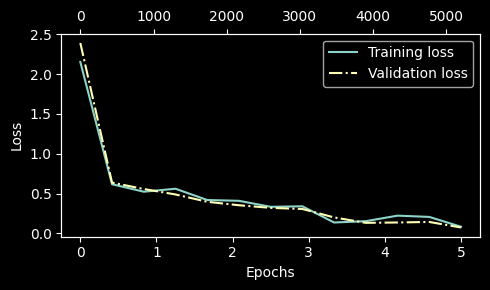

In [108]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

- 图中, 根据训练的斜率, 我们可以发现模型训练的很好
- 此外, 训练和验证损失非常接近可以表明，该模型不会倾向于过拟合训练数据
- 同样的, 我们可以对精度进行绘制

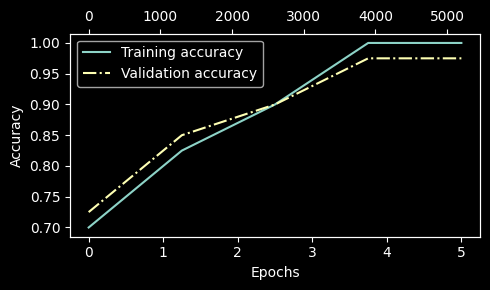

In [109]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

- 根据上面的准确率图，我们可以看到该模型在第 4 个和第 5 循环之后,训练和验证准确率变得相对较高
- 但是，别忘了我们之前在 training 函数中指定了 `eval_iter=5`，这意味着我们只估计了训练和验证集的性能
- 我们可以计算完整数据集的训练、验证和测试集性能，如下所示

In [110]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")
# 输出总的训练集、验证集和测试集的准确率

Training accuracy: 97.21%
Validation accuracy: 97.32%
Test accuracy: 95.67%


- 我们可以看到，训练集和验证集的表现实际上是相同的。
- 然而，由于测试集表现略微较差，我们可以看出，模型在一定程度上对训练数据进行了过拟合，同时也对用于调整超参数（如学习率）的验证数据进行了过拟合。
- 不过，这种情况是正常的，并且通过增加模型的 dropout rate（drop_rate）或优化器设置中的 weight_decay，可能进一步减小这种差距。

## 6.8 使用LLM作为垃圾消息分类器

<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch6/15.png" width=500px>

- 最后，让我们将微调后的 GPT 模型投入实际应用。
- 以下的 `classify_review` 函数实现了类似于我们之前实现的 `SpamDataset` 的数据预处理步骤。
- 然后，函数返回模型预测的整数类别标签，并返回对应的类别名称。

In [111]:
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()
    # 将模型设置为评估模式，禁用dropout等训练特定操作
    input_ids = tokenizer.encode(text)
    # 使用tokenizer将输入文本 转换token ID 列表
    supported_context_length = model.pos_emb.weight.shape[0]
    # 获取模型支持的最大上下文长度（由位置嵌入的权重数量决定）
    input_ids = input_ids[:min(max_length, supported_context_length)]
    # 如果 token 序列长度超过模型支持的最大长度，则进行截断
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    # 对序列进行填充
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0) 
    # 将 token ID 转换为张量并移动到指定设备（如 GPU），同时增加 batch 维度
    # 模型推理
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :] 
        # 禁用梯度计算，仅进行推理
        # 将输入张量传入模型，获取 logits，并提取最后一个 token 的 logits
    predicted_label = torch.argmax(logits, dim=-1).item()
    # 在 logits 上取 softmax 概率最大值的索引，作为预测类别
    return "spam" if predicted_label == 1 else "not spam"
    # 如果预测标签是 `1`，返回 "spam"，否则返回 "not spam"

- 试一下

In [112]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

spam


In [113]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

not spam


- 最后，让我们保存模型，以便以后如果需要重用模型时，无需重新训练。

In [114]:
torch.save(model.state_dict(), "review_classifier.pth")
# 储存!大功告成!

- 下次我们可以这么唤醒这个模型

In [115]:
model_state_dict = torch.load("review_classifier.pth", map_location=device, weights_only=True)
model.load_state_dict(model_state_dict)

<All keys matched successfully>

## 总结

- 请参阅 [./gpt_class_finetune.py](./gpt_class_finetune.py) 脚本，这是一个自包含的分类微调脚本。
- 你可以在 [./exercise-solutions.ipynb](./exercise-solutions.ipynb) 中找到练习解决方案。
- 此外，感兴趣的读者可以在 [附录E](../../appendix-E) 中找到关于低秩适应（LoRA）的参数高效微调的介绍。